<a href="https://colab.research.google.com/github/hanidew/WIE3007-DMW-GroupProject/blob/aliya's-LR/DMW_GA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 1. Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning libraries from Scikit-Learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    f1_score,
    recall_score
)

# LOAD AND INSPEC

In [5]:
# ==========================================
# STEP 1: Load and Inspect Data
# ==========================================

# from google.colab import drive
# drive.mount('/content/drive')

# Load the dataset
filename = '/content/synthetic_data_cleaned_feature_engineered.csv'
df = pd.read_csv(filename, sep='|')

print("✅ Data Loaded Successfully!")
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

✅ Data Loaded Successfully!
Shape: (1091, 13)
Columns: ['Customer_ID', 'Age', 'Annual_Income', 'Credit_Score', 'Loan_Amount', 'Loan_Term_Months', 'Loan_Officer_Note', 'Default_Status', 'Occupation', 'Has_Asset', 'Risk_Flag', 'DTI_Ratio', 'Log_Income']


# DATA PREPROCESSING

In [6]:
# 2.1 Drop columns that are not useful for prediction
# Customer_ID is identifier, Loan_Officer_Note is text
df_clean = df.drop(columns=['Customer_ID', 'Loan_Officer_Note'])

# 2.2 One-Hot Encoding for 'Occupation' (categorical variable)
df_clean = pd.get_dummies(df_clean, columns=['Occupation'], drop_first=True)

# 2.3 Has_Asset is already 0/1, so no mapping needed
# But let's verify it's numeric
if df_clean['Has_Asset'].dtype == 'object':
    asset_mapping = {'Yes': 1, 'No': 0, 1: 1, 0: 0}
    df_clean['Has_Asset'] = df_clean['Has_Asset'].map(asset_mapping)

# Ensure no NaNs in target variable
df_clean.dropna(subset=['Default_Status'], inplace=True)

# 2.4 Define Features (X) and Target (y)
X = df_clean.drop(columns=['Default_Status'])
y = df_clean['Default_Status'].astype(int)

print(f"\n✅ Features: {X.columns.tolist()}")
print(f"✅ Target distribution:\n{y.value_counts()}")

# 2.5 Split Data into Training and Testing Sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 2.6 Feature Scaling (important for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Data Preprocessing Complete.")


✅ Features: ['Age', 'Annual_Income', 'Credit_Score', 'Loan_Amount', 'Loan_Term_Months', 'Has_Asset', 'Risk_Flag', 'DTI_Ratio', 'Log_Income', 'Occupation_Education', 'Occupation_Medical', 'Occupation_Other', 'Occupation_Real Estate', 'Occupation_Retired', 'Occupation_Service', 'Occupation_Student', 'Occupation_Tech', 'Occupation_Trade']
✅ Target distribution:
Default_Status
0    630
1    461
Name: count, dtype: int64
✅ Data Preprocessing Complete.


# TRAIN

In [10]:
# Initialize the Logistic Regression model
# max_iter increased to ensure convergence
# class_weight='balanced' helps with imbalanced data
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight='balanced'  # Helps with imbalanced classes
)

# Handle any potential NaNs in training data
nan_rows = np.isnan(X_train_scaled).any(axis=1)
if nan_rows.any():
    X_train_cleaned = X_train_scaled[~nan_rows]
    y_train_cleaned = y_train.iloc[~nan_rows]
    print(f"⚠️ Warning: Removed {np.sum(nan_rows)} rows containing NaN values from training data.")
else:
    X_train_cleaned = X_train_scaled
    y_train_cleaned = y_train

# Train the model
lr_model.fit(X_train_cleaned, y_train_cleaned)

print("✅ Model Training Complete.")

✅ Model Training Complete.


# EVALUATE TRAINING SET

In [12]:
from sklearn.metrics import precision_score

print("\n" + "="*50)
print("LOGISTIC REGRESSION MODEL PERFORMANCE ON TRAINING DATA")
print("="*50)

# Make predictions on the training set
y_train_pred = lr_model.predict(X_train_scaled)
y_train_prob = lr_model.predict_proba(X_train_scaled)[:, 1] # Probability for class 1 (Default)

# Calculate core metrics for training set
metric_train_accuracy = accuracy_score(y_train_cleaned, y_train_pred)
metric_train_precision = precision_score(y_train_cleaned, y_train_pred)
metric_train_recall = recall_score(y_train_cleaned, y_train_pred)
metric_train_f1 = f1_score(y_train_cleaned, y_train_pred)
metric_train_auc = roc_auc_score(y_train_cleaned, y_train_prob)

# Print detailed performance metrics
print(f"Accuracy:   {metric_train_accuracy:.4f} ({metric_train_accuracy:.2%})")
print(f"Precision:  {metric_train_precision:.4f} ({metric_train_precision:.2%})")
print(f"Recall:     {metric_train_recall:.4f} ({metric_train_recall:.2%})")
print(f"F1-Score:   {metric_train_f1:.4f}")
print(f"ROC-AUC:    {metric_train_auc:.4f}")

print("\n" + "-"*50)
print("CLASSIFICATION REPORT (TRAINING SET)")
print("-"*50)
print(classification_report(y_train_cleaned, y_train_pred, target_names=['Paid (0)', 'Default (1)']))


LOGISTIC REGRESSION MODEL PERFORMANCE ON TRAINING DATA
Accuracy:   0.8773 (87.73%)
Precision:  0.8967 (89.67%)
Recall:     0.8016 (80.16%)
F1-Score:   0.8465
ROC-AUC:    0.9061

--------------------------------------------------
CLASSIFICATION REPORT (TRAINING SET)
--------------------------------------------------
              precision    recall  f1-score   support

    Paid (0)       0.87      0.93      0.90       504
 Default (1)       0.90      0.80      0.85       368

    accuracy                           0.88       872
   macro avg       0.88      0.87      0.87       872
weighted avg       0.88      0.88      0.88       872



# EVALUATION AND METRICS

In [13]:
# Make predictions on the test set
y_pred = lr_model.predict(X_test_scaled)
y_prob = lr_model.predict_proba(X_test_scaled)[:, 1]  # Probability for ROC-AUC

# Calculate core metrics
metric_accuracy = accuracy_score(y_test, y_pred)
metric_recall = recall_score(y_test, y_pred)
metric_f1 = f1_score(y_test, y_pred)
metric_auc = roc_auc_score(y_test, y_prob)

# Get feature importance (coefficients)
feature_names = X.columns
coefficients = lr_model.coef_[0]

# Create a Series for feature importance (absolute values)
feature_importance_series = pd.Series(np.abs(coefficients), index=feature_names)
top_features = feature_importance_series.nlargest(5)

# Format the top features into a string
top_features_str = "\n".join([f"- {name}: {value:.4f}" for name, value in top_features.items()])

# Print Core Metrics
print("\n" + "="*40)
print("LOGISTIC REGRESSION MODEL PERFORMANCE")
print("="*40)
print(f"Accuracy:  {metric_accuracy:.4f}")
print(f"Recall:    {metric_recall:.4f} (Crucial for catching defaulters)")
print(f"F1-Score:  {metric_f1:.4f} (Balance of Precision/Recall)")
print(f"ROC-AUC:   {metric_auc:.4f}")
print("\nTop 5 Most Important Features:")
print(top_features_str)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=['Paid', 'Default']))



LOGISTIC REGRESSION MODEL PERFORMANCE
Accuracy:  0.8265
Recall:    0.7097 (Crucial for catching defaulters)
F1-Score:  0.7765 (Balance of Precision/Recall)
ROC-AUC:   0.8972

Top 5 Most Important Features:
- DTI_Ratio: 1.9516
- Risk_Flag: 1.7054
- Has_Asset: 0.3327
- Loan_Amount: 0.2471
- Credit_Score: 0.2355

Classification Report:

              precision    recall  f1-score   support

        Paid       0.81      0.91      0.86       126
     Default       0.86      0.71      0.78        93

    accuracy                           0.83       219
   macro avg       0.83      0.81      0.82       219
weighted avg       0.83      0.83      0.82       219



# VISUALISATIONS


GENERATING VISUALIZATIONS


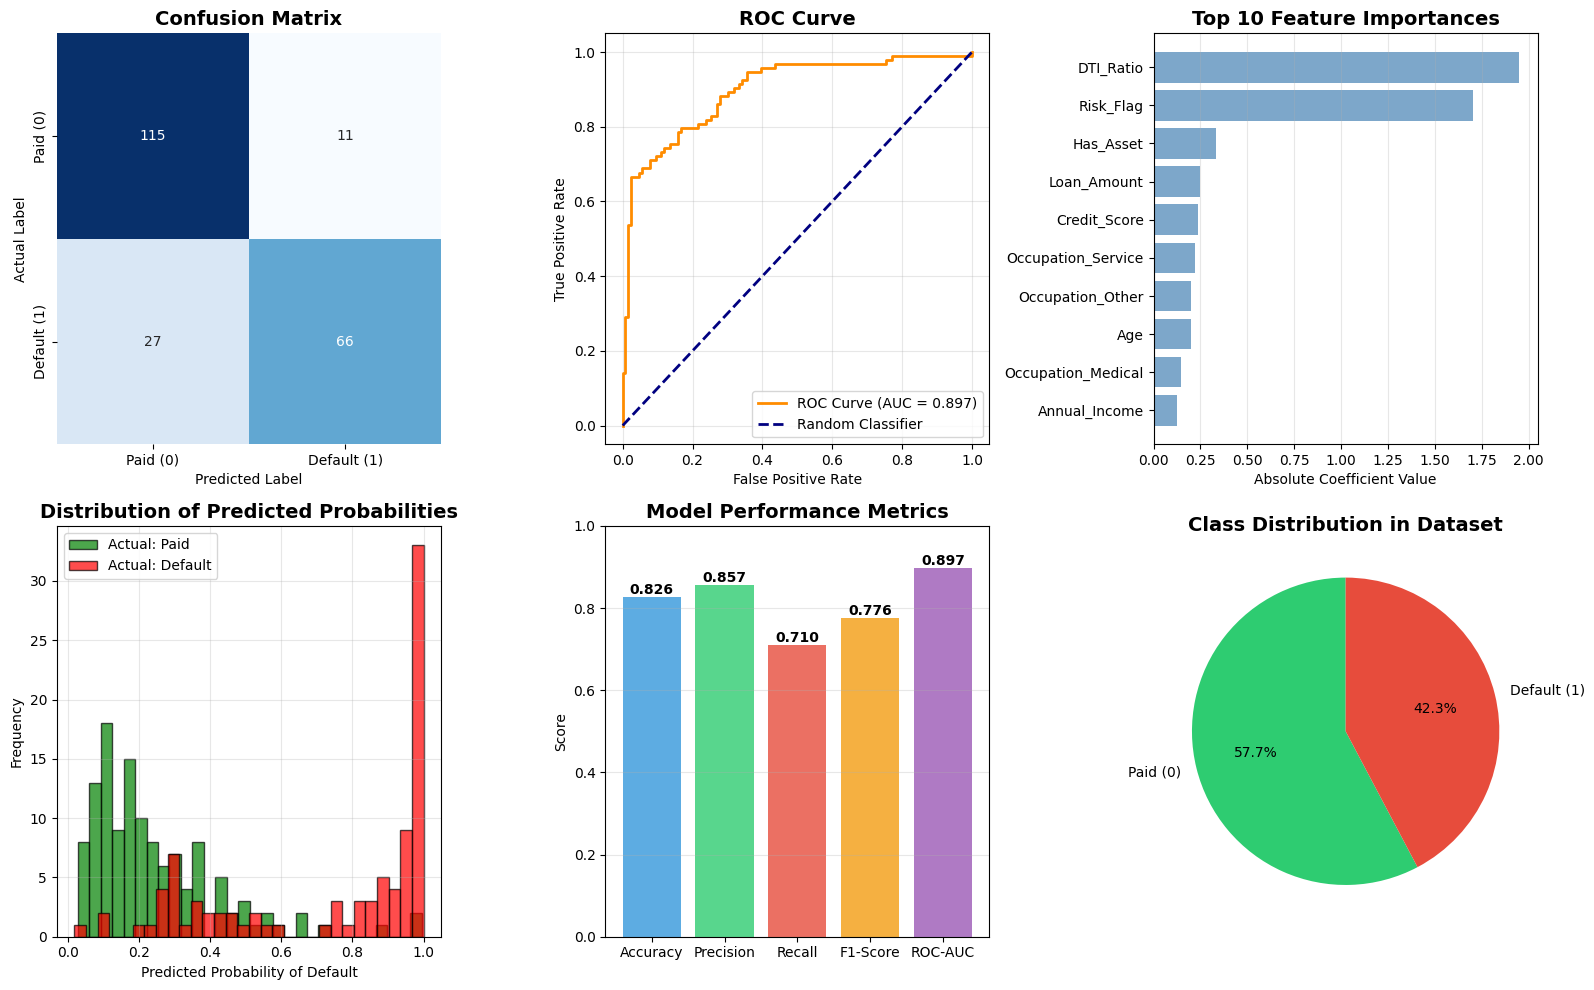

✅ Visualizations Generated.


In [15]:
print("\n" + "="*50)
print("GENERATING VISUALIZATIONS")
print("="*50)

# Calculate metric_precision for the test set, as it was missing from previous calculations
# This ensures all metrics for the bar chart are defined.
metric_precision = precision_score(y_test, y_pred)

# Create a comprehensive visualization
fig = plt.figure(figsize=(16, 10))

# 5.1 Confusion Matrix
ax1 = plt.subplot(2, 3, 1)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax1)
ax1.set_title('Confusion Matrix', fontsize=14, fontweight='bold')
ax1.set_xlabel('Predicted Label')
ax1.set_ylabel('Actual Label')
ax1.set_xticklabels(['Paid (0)', 'Default (1)'])
ax1.set_yticklabels(['Paid (0)', 'Default (1)'])

# 5.2 ROC Curve
ax2 = plt.subplot(2, 3, 2)
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
ax2.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'ROC Curve (AUC = {metric_auc:.3f})')
ax2.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC Curve', fontsize=14, fontweight='bold')
ax2.legend(loc="lower right")
ax2.grid(True, alpha=0.3)

# 5.3 Feature Importance (Top 10)
ax3 = plt.subplot(2, 3, 3)
# Corrected: Use feature_importance_series and get nlargest(10)
top_10_features_plot = feature_importance_series.nlargest(10)
# Since feature_importance_series contains absolute values, using a single color is appropriate.
ax3.barh(top_10_features_plot.index, top_10_features_plot.values, color='steelblue', alpha=0.7)
ax3.set_xlabel('Absolute Coefficient Value')
ax3.set_title('Top 10 Feature Importances', fontsize=14, fontweight='bold')
ax3.grid(True, alpha=0.3, axis='x')
ax3.invert_yaxis() # Display largest at the top

# 5.4 Prediction Distribution
ax4 = plt.subplot(2, 3, 4)
ax4.hist(y_prob[y_test == 0], bins=30, alpha=0.7, label='Actual: Paid', color='green', edgecolor='black')
ax4.hist(y_prob[y_test == 1], bins=30, alpha=0.7, label='Actual: Default', color='red', edgecolor='black')
ax4.set_xlabel('Predicted Probability of Default')
ax4.set_ylabel('Frequency')
ax4.set_title('Distribution of Predicted Probabilities', fontsize=14, fontweight='bold')
ax4.legend()
ax4.grid(True, alpha=0.3)

# 5.5 Performance Metrics Bar Chart
ax5 = plt.subplot(2, 3, 5)
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
metrics_values = [metric_accuracy, metric_precision, metric_recall, metric_f1, metric_auc]
bars = ax5.bar(metrics_names, metrics_values, color=['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6'], alpha=0.8)
ax5.set_ylabel('Score')
ax5.set_title('Model Performance Metrics', fontsize=14, fontweight='bold')
ax5.set_ylim(0, 1)
ax5.grid(True, alpha=0.3, axis='y')
# Add value labels on bars
for bar, value in zip(bars, metrics_values):
    height = bar.get_height()
    ax5.text(bar.get_x() + bar.get_width()/2., height,
             f'{value:.3f}',
             ha='center', va='bottom', fontweight='bold')

# 5.6 Class Distribution
ax6 = plt.subplot(2, 3, 6)
class_counts = y.value_counts()
ax6.pie(class_counts.values, labels=['Paid (0)', 'Default (1)'],
        autopct='%1.1f%%', startangle=90, colors=['#2ecc71', '#e74c3c'])
ax6.set_title('Class Distribution in Dataset', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("✅ Visualizations Generated.")

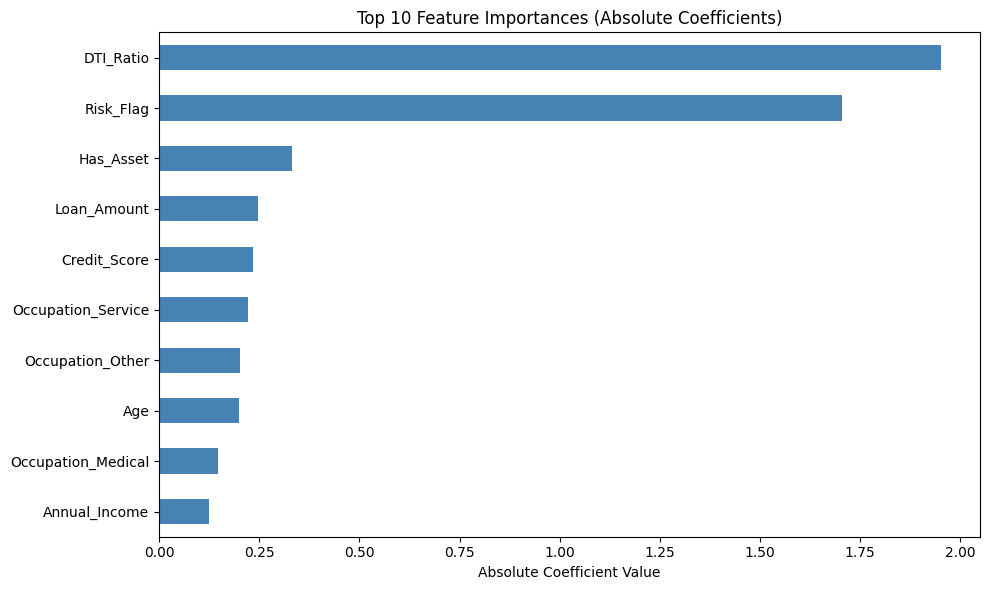

In [16]:
# ==========================================
# STEP 6: Feature Importance Visualization
# ==========================================

plt.figure(figsize=(10, 6))
top_10_features = feature_importance_series.sort_values().tail(10)
top_10_features.plot(kind='barh', color='steelblue')
plt.title('Top 10 Feature Importances (Absolute Coefficients)')
plt.xlabel('Absolute Coefficient Value')
plt.tight_layout()
plt.show()

# INTERPRETATION

In [17]:
# ==========================================
# STEP 7: Display Coefficient Interpretation
# ==========================================

print("\n" + "="*40)
print("COEFFICIENT INTERPRETATION")
print("="*40)
print("Positive coefficients → Increase default probability")
print("Negative coefficients → Decrease default probability")
print("\nTop 5 Positive Predictors of Default:")
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
}).sort_values('Coefficient', ascending=False)
print(coef_df.head())
print("\nTop 5 Negative Predictors of Default:")
print(coef_df.tail())


COEFFICIENT INTERPRETATION
Positive coefficients → Increase default probability
Negative coefficients → Decrease default probability

Top 5 Positive Predictors of Default:
               Feature  Coefficient
7            DTI_Ratio     1.951612
6            Risk_Flag     1.705394
2         Credit_Score     0.235483
0                  Age     0.200396
10  Occupation_Medical     0.146631

Top 5 Negative Predictors of Default:
               Feature  Coefficient
17    Occupation_Trade    -0.083994
11    Occupation_Other    -0.201903
14  Occupation_Service    -0.222424
3          Loan_Amount    -0.247055
5            Has_Asset    -0.332691


In [ ]:

# ==========================================
# PART B: THE LLM ANALYSIS (The Insight)
# ==========================================

print("\n" + "="*50)
print("PREPARING LLM ANALYSIS")
print("="*50)

# Install bitsandbytes if needed
!pip install -q -U bitsandbytes

print("⏳ Loading LLM for Analysis...")

import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig, pipeline

# Setup Model with 4-bit quantization for efficiency
model_name = "microsoft/Phi-3-mini-4k-instruct"

quant_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4"
)

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=quant_config,
    device_map="auto"
)

print("✅ LLM Loaded Successfully!")

# Construct the Prompt with your specific data
analysis_prompt = f"""[INST] You are a Data Science Expert specializing in credit risk analysis.

I have trained a Logistic Regression model to predict Loan Defaults using customer financial data including Age, Annual Income, Credit Score, Loan Amount, and Loan Term.

Please analyze the performance metrics and feature importance listed below.

### MODEL PERFORMANCE:
- Accuracy: {metric_accuracy:.2%} (Overall correct predictions)
- Precision: {metric_precision:.2%} (Of predicted defaults, how many were correct)
- Recall: {metric_recall:.2%} (Of actual defaults, how many did we catch)
- F1-Score: {metric_f1:.4f} (Balance between Precision and Recall)
- ROC-AUC: {metric_auc:.4f} (Model's ability to discriminate between classes)

### TOP 5 MOST IMPORTANT FEATURES (Logistic Regression Coefficients):
{top_features_str}

Note: Positive coefficients increase default probability, negative coefficients decrease it.

### DATASET CONTEXT:
- Total samples: {len(df)}
- Default rate: {y.mean():.2%}
- Features include: Age, Annual Income, Credit Score, Loan Amount, Loan Term (months)

### INSTRUCTIONS:
1. Summarize the model's performance. Is it suitable for real-world credit risk management? Consider the trade-off between catching defaulters (recall) and avoiding false alarms (precision).

2. Interpret the Top 5 Features. Explain why each feature's coefficient (positive or negative) makes business sense in predicting loan defaults.

3. Provide TWO specific business recommendations:
   a) One for improving the model's performance
   b) One for how the bank should use these insights in their loan approval process
[/INST]"""

# Generate the Analysis
print("\n🤖 Generating Analysis from LLM...")
print("This may take 1-2 minutes...\n")

generator = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    max_new_tokens=1024,
    do_sample=True,
    temperature=0.1,
    repetition_penalty=1.0
)

output = generator(analysis_prompt)
generated_text = output[0]['generated_text']

# Display Result
print("\n" + "="*60)
print("📊 LLM AUTOMATED FINDINGS & INSIGHTS")
print("="*60)
# Extract only the response part (after [/INST])
llm_response = generated_text.split("[/INST]")[-1].strip()
print(llm_response)

print("\n" + "="*60)
print("✅ ANALYSIS COMPLETE!")
print("="*60)


PREPARING LLM ANALYSIS
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 MB 11.6 MB/s eta 0:00:00
⏳ Loading LLM for Analysis...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/181 [00:00<?, ?B/s]

Device set to use cpu


✅ LLM Loaded Successfully!

🤖 Generating Analysis from LLM...
This may take 1-2 minutes...



KeyboardInterrupt: 